In [137]:
#plain backtracking

import matplotlib.pyplot as plt
import networkx as nx

states = ["AP","AR","AS","BR","CG","GA","GJ","HR","HP","JH","KA","KL","MP","MH","MN","ML","MZ","NL","OD","PB","RJ","SK","TN","TS","TR","UP","UK","WB","JK"]
values = ["red",'green','blue','yellow']

adj_list = {
    "AP": ["TS", "OD", "TN", "KA"],
    "AR": ["AS", "NL"],
    "AS": ["AR", "NL", "ML", "TR", "MZ", "MN", "WB"],
    "BR": ["UP", "JH", "WB"],
    "CG": ["UP", "JH", "OD", "MH"],
    "GA": ["MH", "KA"],
    "GJ": ["MH", "RJ"],
    "HR": ["PB", "HP", "UK", "RJ"],
    "HP": ["JK", "PB", "HR", "UK"],
    "JH": ["BR", "UP", "CG", "OD", "WB"],
    "KA": ["MH", "AP", "TS", "TN", "KL", "GA"],
    "KL": ["KA", "TN"],
    "MP": ["RJ", "UP", "CG", "MH", "GJ"],
    "MH": ["GJ", "MP", "CG", "TS", "KA", "GA"],
    "MN": ["AS", "MZ", "NL"],
    "ML": ["AS", "TR"],
    "MZ": ["AS", "MN", "TR"],
    "NL": ["AR", "AS", "MN"],
    "OD": ["WB", "JH", "CG", "AP", "TS"],
    "PB": ["JK", "HP", "HR", "RJ"],
    "RJ": ["PB", "HR", "MP", "GJ", "UP"],
    "SK": ["WB"],
    "TN": ["AP", "KA", "KL"],
    "TS": ["MH", "KA", "AP", "OD"],
    "TR": ["AS", "ML", "MZ"],
    "UP": ["UK", "HR", "RJ", "MP", "CG", "JH", "BR"],
    "UK": ["HP", "HR", "UP"],
    "WB": ["BR", "JH", "OD", "AS", "SK"],
    "JK": []
}

for state, neighbors in list(adj_list.items()):
    for neighbor in neighbors:
        if neighbor not in adj_list:
            adj_list[neighbor] = []
        if state not in adj_list[neighbor]:
            adj_list[neighbor].append(state)

In [138]:
def is_valid(assigned, state, color):
    for neighbor in adj_list[state]:
        if neighbor in assigned and assigned[neighbor] == color:
            return False
    return True

In [139]:
plain_steps = 0
def plain_backtracking(assigned):
    global plain_steps
    plain_steps += 1

    if len(assigned) == len(states):
        return assigned

    for state in states:
        if state not in assigned:
            break
    for value in values:
        if is_valid(assigned, state, value):
            assigned[state] = value
            result = plain_backtracking(assigned)
            if result is not None:
                return result
            del assigned[state]
    return None

In [140]:
def viz_col(solution, title):
  G = nx.Graph()

  for state in states:
    G.add_node(state)

  for state, neighbors in adj_list.items():
    for neighbor in neighbors:
      G.add_edge(state, neighbor)

  pos = nx.spring_layout(G)

  node_colors = [solution.get(node,"white") for node in G.nodes()]

  plt.figure(figsize=(10, 8))
  nx.draw(
      G, pos,
      with_labels = True,
      node_color = node_colors,
      font_size = 12,
      font_weight = "bold",
      edge_color = "black"
  )
  plt.title(title)
  plt.show()

{'AP': 'red', 'AR': 'red', 'AS': 'green', 'BR': 'red', 'CG': 'red', 'GA': 'red', 'GJ': 'red', 'HR': 'red', 'HP': 'green', 'JH': 'green', 'KA': 'green', 'KL': 'red', 'MP': 'green', 'MH': 'blue', 'MN': 'red', 'ML': 'red', 'MZ': 'blue', 'NL': 'blue', 'OD': 'blue', 'PB': 'blue', 'RJ': 'yellow', 'SK': 'red', 'TN': 'blue', 'TS': 'yellow', 'TR': 'yellow', 'UP': 'blue', 'UK': 'yellow', 'WB': 'yellow', 'JK': 'red'}


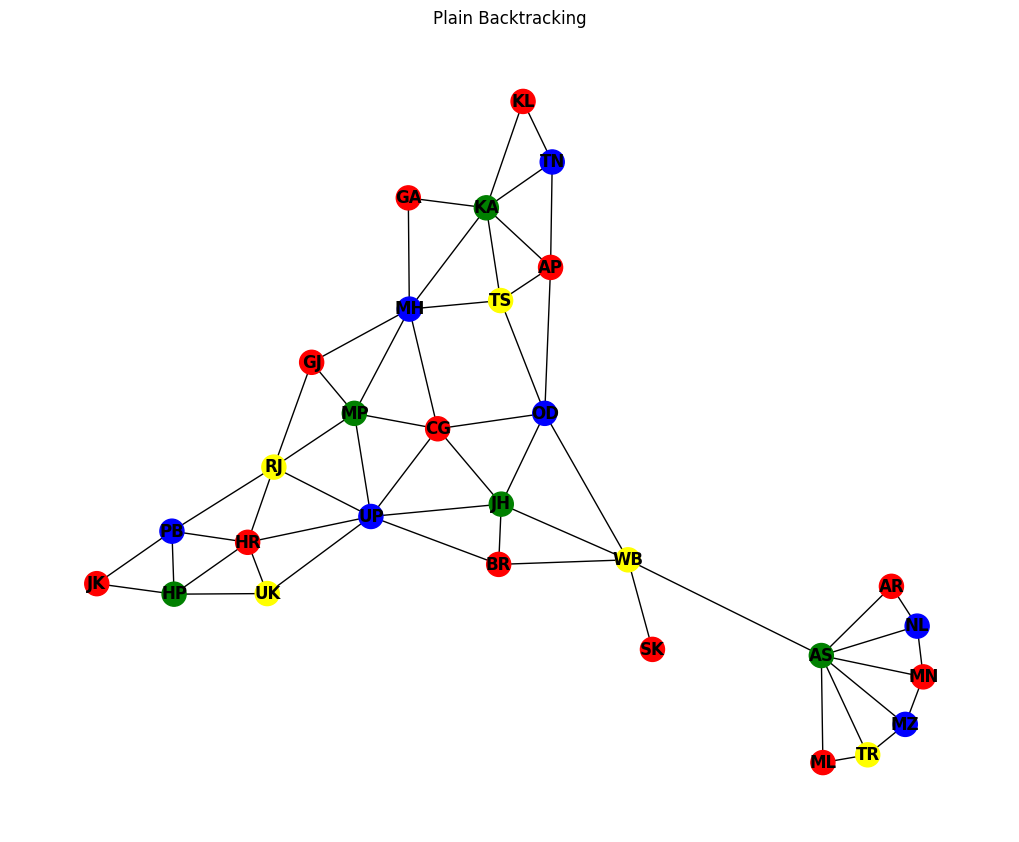

In [141]:
if __name__ == "__main__":
    plain_sol = plain_backtracking({})
    print(plain_sol)
    viz_col(plain_sol, "Plain Backtracking")

In [142]:
#backtracking with mrv + lcv

def select_unassigned(assigned):
    unassigned = [v for v in states if v not in assigned]
    return min(unassigned, key=lambda var: len([c for c in values if is_valid(assigned, var, c)]))

def order_domain(var, assigned):
    def conflicts(color):
        count = 0
        for neighbor in adj_list[var]:
            if neighbor not in assigned:
                valid = [c for c in values if c != color and is_valid(assigned, neighbor, c)]
                count += len(valid)
        return -count
    return sorted(values, key=conflicts)

heuristic_steps = 0
def backtracking_with_mrv_lcv(assigned):
    global heuristic_steps
    heuristic_steps += 1

    if len(assigned) == len(states):
        return assigned

    var = select_unassigned(assigned)
    domain_order = order_domain(var, assigned)

    print(f"Step {heuristic_steps}: MRV selected {var}, LCV order = {domain_order}")

    for value in domain_order:
        if is_valid(assigned, var, value):
            assigned[var] = value
            result = backtracking_with_mrv_lcv(assigned)
            if result is not None:
                return result
            del assigned[var]
    return None

Step 1: MRV selected AP, LCV order = ['red', 'green', 'blue', 'yellow']
Step 2: MRV selected KA, LCV order = ['red', 'green', 'blue', 'yellow']
Step 3: MRV selected TN, LCV order = ['green', 'red', 'blue', 'yellow']
Step 4: MRV selected KL, LCV order = ['red', 'green', 'blue', 'yellow']
Step 5: MRV selected TS, LCV order = ['red', 'green', 'blue', 'yellow']
Step 6: MRV selected MH, LCV order = ['green', 'red', 'blue', 'yellow']
Step 7: MRV selected GA, LCV order = ['red', 'green', 'blue', 'yellow']
Step 8: MRV selected OD, LCV order = ['red', 'green', 'blue', 'yellow']
Step 9: MRV selected CG, LCV order = ['red', 'green', 'blue', 'yellow']
Step 10: MRV selected JH, LCV order = ['green', 'blue', 'red', 'yellow']
Step 11: MRV selected MP, LCV order = ['red', 'blue', 'green', 'yellow']
Step 12: MRV selected UP, LCV order = ['red', 'green', 'blue', 'yellow']
Step 13: MRV selected BR, LCV order = ['red', 'green', 'blue', 'yellow']
Step 14: MRV selected GJ, LCV order = ['green', 'yellow', 'r

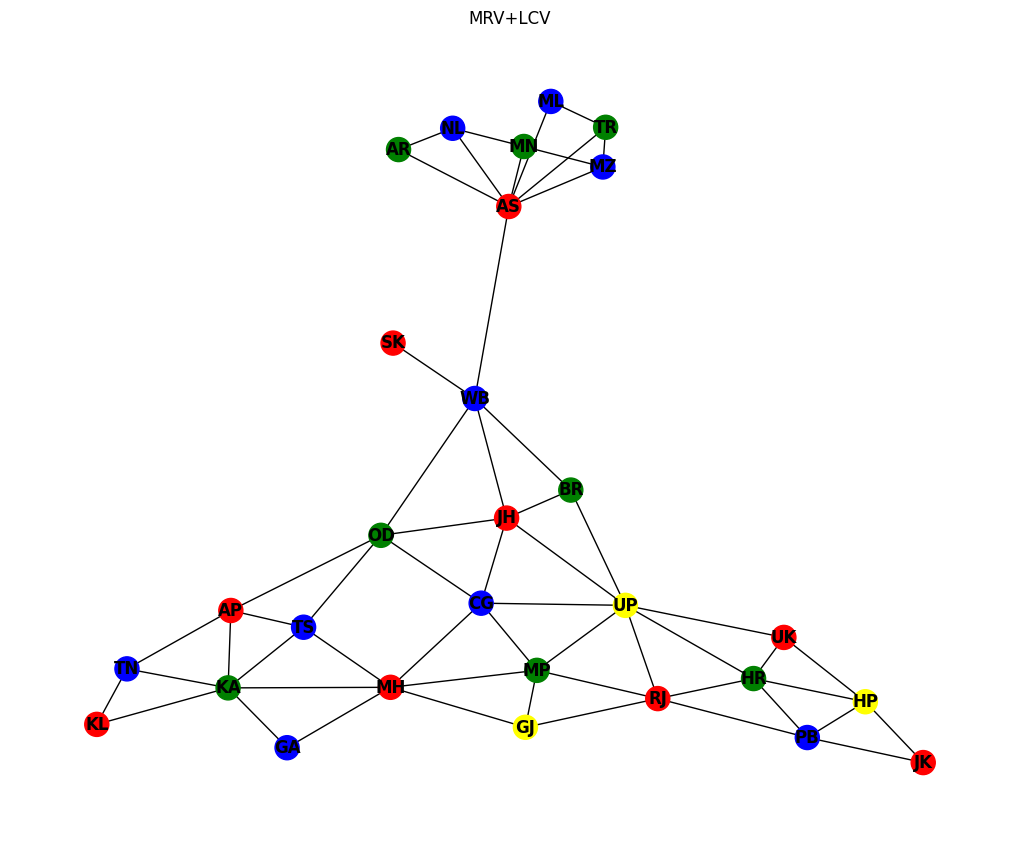

In [143]:
if __name__ == "__main__":

    heuristic_sol = backtracking_with_mrv_lcv({})
    print("backtracking with mrv + lcv ", heuristic_sol)
    print("steps ",heuristic_steps)
    viz_col(heuristic_sol,"MRV+LCV")

In [144]:
from collections import deque

def ac3(domains):
    queue = deque([(xi, xj) for xi in states for xj in adj_list[xi]])
    while queue:
        xi, xj = queue.popleft()
        if revise(domains, xi, xj):
            if not domains[xi]:
                return False  #domain wipeout -> failure
            for xk in adj_list[xi]:
                if xk != xj:
                    queue.append((xk, xi))
    return True

def revise(domains, xi, xj):
    #revise domain of xi with respect to xj
    revised = False
    for x in set(domains[xi]):
        #if no value in xj's domain is consistent with x, remove x
        if all(x == y for y in domains[xj]):
            domains[xi].remove(x)
            revised = True
    return revised

In [145]:
ac3_steps = 0

def backtracking_with_ac3(assigned, domains):
    global ac3_steps
    ac3_steps += 1

    if len(assigned) == len(states):
        return assigned

    var = min([v for v in states if v not in assigned],
              key=lambda v: len(domains[v]))
    domain_order = sorted(domains[var], key=lambda val: lcv_heuristic(var, val, domains))

    print(f"Step {ac3_steps}: MRV picked {var}, LCV order = {domain_order}")

    for value in domain_order:
        new_domains = {k: set(v) for k, v in domains.items()}  # copy
        if value in new_domains[var]:
            new_domains[var] = {value}
            if ac3(new_domains):  # constraint propagation
                assigned[var] = value
                result = backtracking_with_ac3(assigned, new_domains)
                if result is not None:
                    return result
                del assigned[var]
    return None

def lcv_heuristic(var, value, domains):
    return sum(value in domains[nbr] for nbr in adj_list[var])

Plain Backtracking: {'AP': 'red', 'AR': 'red', 'AS': 'green', 'BR': 'red', 'CG': 'red', 'GA': 'red', 'GJ': 'red', 'HR': 'red', 'HP': 'green', 'JH': 'green', 'KA': 'green', 'KL': 'red', 'MP': 'green', 'MH': 'blue', 'MN': 'red', 'ML': 'red', 'MZ': 'blue', 'NL': 'blue', 'OD': 'blue', 'PB': 'blue', 'RJ': 'yellow', 'SK': 'red', 'TN': 'blue', 'TS': 'yellow', 'TR': 'yellow', 'UP': 'blue', 'UK': 'yellow', 'WB': 'yellow', 'JK': 'red'}


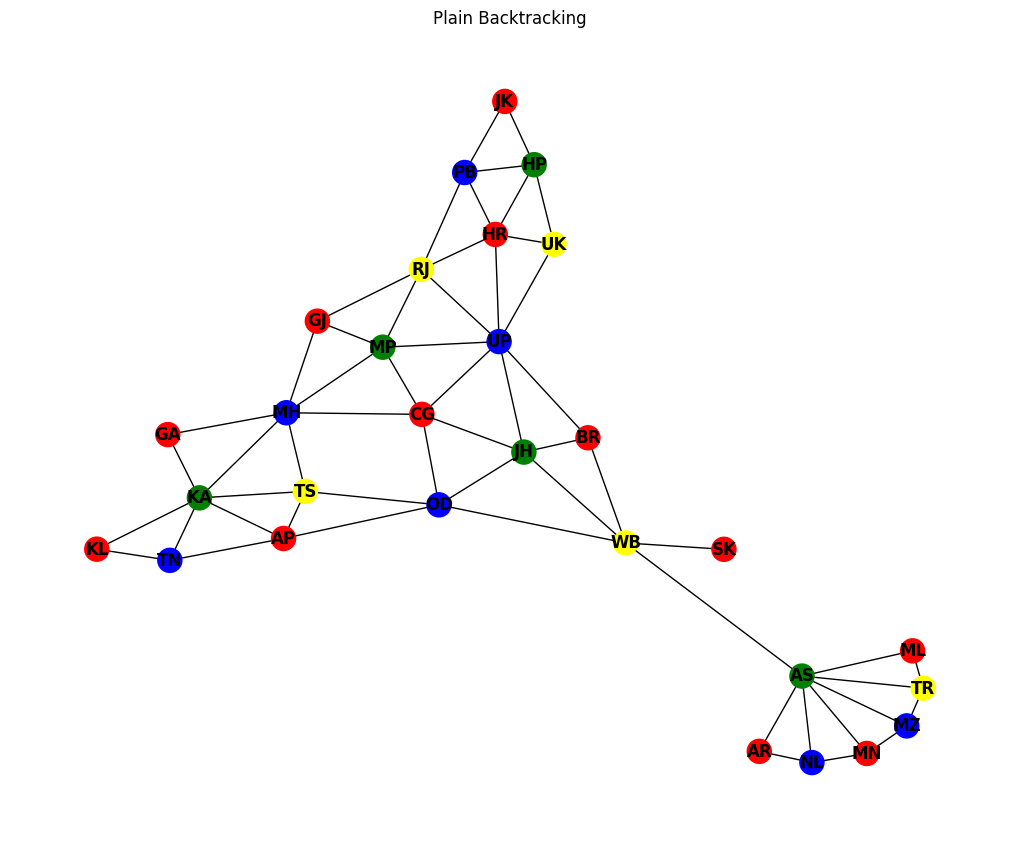

Step 31: MRV selected AP, LCV order = ['red', 'green', 'blue', 'yellow']
Step 32: MRV selected KA, LCV order = ['red', 'green', 'blue', 'yellow']
Step 33: MRV selected TN, LCV order = ['green', 'red', 'blue', 'yellow']
Step 34: MRV selected KL, LCV order = ['red', 'green', 'blue', 'yellow']
Step 35: MRV selected TS, LCV order = ['red', 'green', 'blue', 'yellow']
Step 36: MRV selected MH, LCV order = ['green', 'red', 'blue', 'yellow']
Step 37: MRV selected GA, LCV order = ['red', 'green', 'blue', 'yellow']
Step 38: MRV selected OD, LCV order = ['red', 'green', 'blue', 'yellow']
Step 39: MRV selected CG, LCV order = ['red', 'green', 'blue', 'yellow']
Step 40: MRV selected JH, LCV order = ['green', 'blue', 'red', 'yellow']
Step 41: MRV selected MP, LCV order = ['red', 'blue', 'green', 'yellow']
Step 42: MRV selected UP, LCV order = ['red', 'green', 'blue', 'yellow']
Step 43: MRV selected BR, LCV order = ['red', 'green', 'blue', 'yellow']
Step 44: MRV selected GJ, LCV order = ['green', 'ye

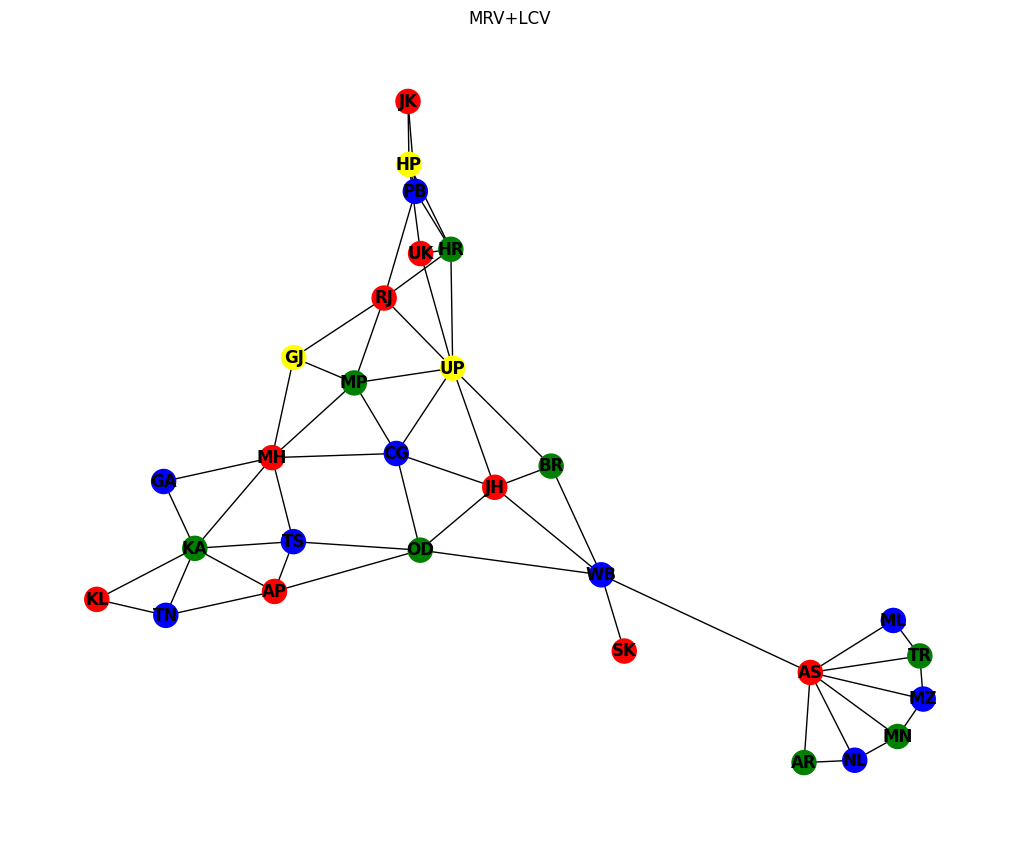

Step 1: MRV picked AP, LCV order = ['blue', 'green', 'red', 'yellow']
Step 2: MRV picked KA, LCV order = ['green', 'red', 'yellow']
Step 3: MRV picked TN, LCV order = ['red', 'yellow']
Step 4: MRV picked KL, LCV order = ['blue', 'yellow']
Step 5: MRV picked TS, LCV order = ['red', 'yellow']
Step 6: MRV picked MH, LCV order = ['blue', 'yellow']
Step 7: MRV picked GA, LCV order = ['red', 'yellow']
Step 8: MRV picked OD, LCV order = ['green', 'yellow']
Step 9: MRV picked CG, LCV order = ['red', 'yellow']
Step 10: MRV picked JH, LCV order = ['blue', 'yellow']
Step 11: MRV picked MP, LCV order = ['green', 'yellow']
Step 12: MRV picked UP, LCV order = ['yellow']
Step 13: MRV picked BR, LCV order = ['green', 'red']
Step 14: MRV picked GJ, LCV order = ['yellow', 'red']
Step 15: MRV picked RJ, LCV order = ['blue', 'red']
Step 16: MRV picked HR, LCV order = ['green', 'red']
Step 17: MRV picked PB, LCV order = ['red', 'yellow']
Step 18: MRV picked HP, LCV order = ['yellow', 'blue']
Step 19: MRV p

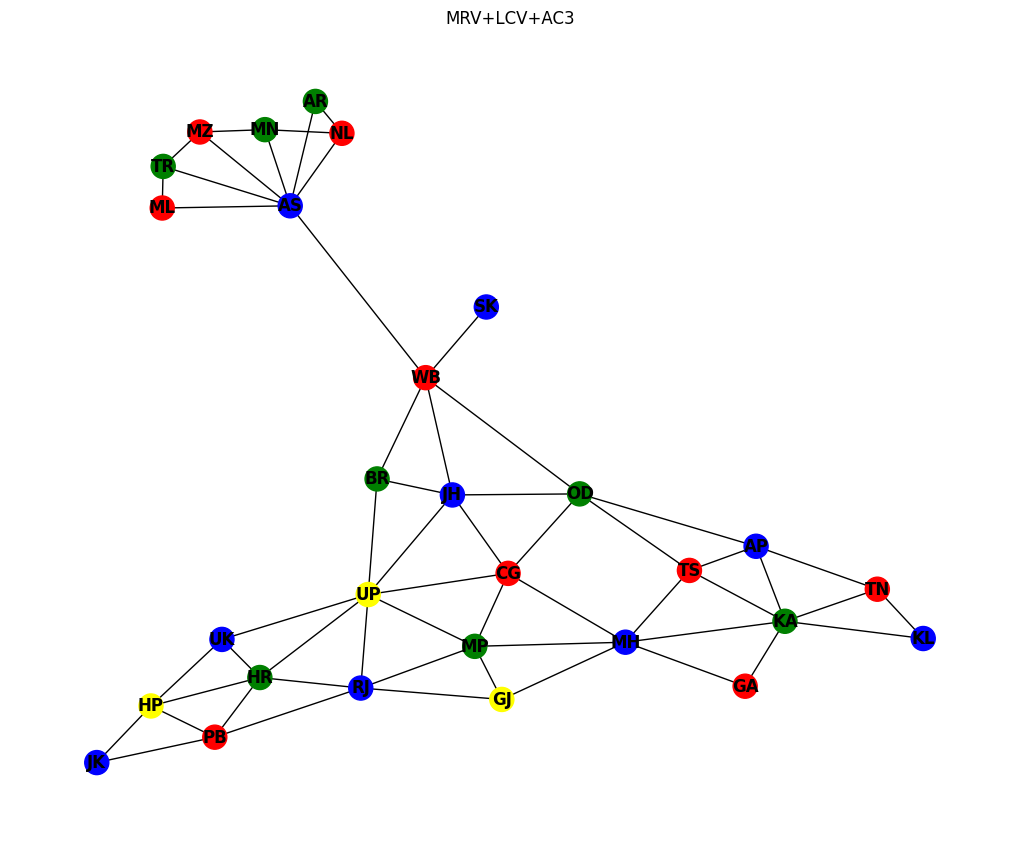


Step Comparison:
+--------------------+---------+
| Algorithm          |   Steps |
+====================+=========+
| Plain Backtracking |      60 |
+--------------------+---------+
| MRV+LCV            |      60 |
+--------------------+---------+
| MRV+LCV+AC-3       |      30 |
+--------------------+---------+


In [146]:
if __name__ == "__main__":
    plain_sol = plain_backtracking({})
    print("Plain Backtracking:", plain_sol)
    viz_col(plain_sol, "Plain Backtracking")

    heuristic_sol = backtracking_with_mrv_lcv({})
    print("MRV+LCV:", heuristic_sol)
    viz_col(heuristic_sol, "MRV+LCV")

    domains = {v: set(values) for v in states}
    ac3_sol = backtracking_with_ac3({}, domains)
    print("MRV+LCV+AC3:", ac3_sol)
    viz_col(ac3_sol, "MRV+LCV+AC3")

    table = [
        ["Plain Backtracking", plain_steps],
        ["MRV+LCV", heuristic_steps],
        ["MRV+LCV+AC-3", ac3_steps],
    ]
    from tabulate import tabulate
    print("\nStep Comparison:")
    print(tabulate(table, headers=["Algorithm", "Steps"], tablefmt="grid"))